Importando as bibliotecas

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

Load the dataset

In [2]:
df = sns.load_dataset('iris')

EDA

In [3]:
print("--- PRIMEIRAS LINHAS DO DATASET ---")
print(df.head())


--- PRIMEIRAS LINHAS DO DATASET ---
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [4]:
print("\n--- CONTAGEM DE CADA CLASSE ---")
print(df['species'].value_counts())


--- CONTAGEM DE CADA CLASSE ---
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


Visualização

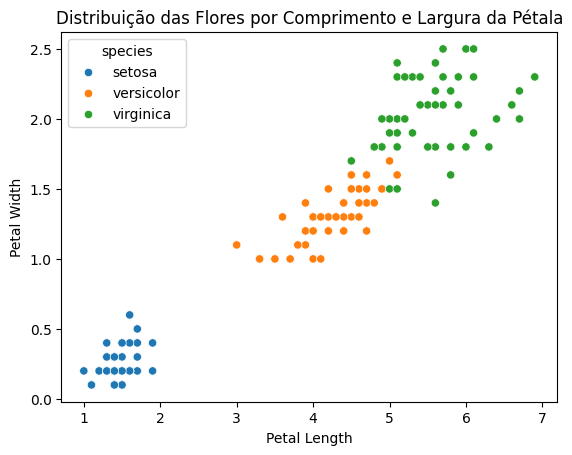

In [5]:
sns.scatterplot (data=df, x='petal_length', y='petal_width', hue='species') #hue para colorir os pontos de acordo com a espécie
plt.title('Distribuição das Flores por Comprimento e Largura da Pétala')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.show()

Dados de treino e teste

Dados de treino e teste são usados para avaliar o desempenho do modelo.
O modelo é treinado com os dados de treino e depois testado com os dados de teste para verificar sua capacidade de generalização.

Dados de treino: usados para ajustar os parâmetros do modelo. E são 70% dos dados originais.
Dados de teste: usados para avaliar o desempenho do modelo. E são 30% dos dados originais.

Separando as perguntas (x) das respostas (y)

In [6]:
x = df.drop(columns='species') #todas as colunas menos a coluna 'species'
y = df['species']


Dividindo os dados em treino e teste

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42) #test_size para definir a proporção de dados de teste, random_state para garantir a reprodutibilidade igual a 42


É preciso normalizar os dados para que o modelo KNN funcione corretamente, pois ele é baseado na distância entre os pontos.
Se os dados não forem normalizados, as características com valores maiores podem dominar a distância e afetar

Normalização dos dados

In [8]:
scaler = MinMaxScaler() #padronizando para uma escala de 0 a 1
x_train = scaler.fit_transform(x_train) #ajustando o scaler aos dados de treino e transformando os dados de treino
x_test = scaler.transform(x_test) #transformando os dados de teste usando o mesmo scaler


In [9]:
print("\n--- DADOS NORMALIZADOS ---")
print("Dados de Treino:\n", x_train[:5]) #mostrando as primeiras 5 linhas dos dados de treino normalizados
print("\nDados de Teste:\n", x_test[:5]) #mostrando as primeiras 5 linhas dos dados de teste normalizados



--- DADOS NORMALIZADOS ---
Dados de Treino:
 [[0.35294118 0.18181818 0.46428571 0.375     ]
 [0.58823529 0.36363636 0.71428571 0.58333333]
 [0.61764706 0.5        0.78571429 0.70833333]
 [0.67647059 0.45454545 0.58928571 0.54166667]
 [0.85294118 0.72727273 0.89285714 1.        ]]

Dados de Teste:
 [[0.52941176 0.36363636 0.64285714 0.45833333]
 [0.41176471 0.81818182 0.10714286 0.08333333]
 [1.         0.27272727 1.03571429 0.91666667]
 [0.5        0.40909091 0.60714286 0.58333333]
 [0.73529412 0.36363636 0.66071429 0.54166667]]


Criando o modelo KNN

In [10]:
knn = KNeighborsClassifier(n_neighbors=5) #criando o modelo KNN com k=5

Treinando o modelo

In [11]:
knn.fit(x_train, y_train) #ajustando o modelo aos dados de treino

KNeighborsClassifier()

In [12]:
print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


Hora de fazer as previsões

In [13]:
previsoes = knn.predict(x_test) #fazendo as previsões com os dados de teste

Avaliação do modelo/Medindo a acurácia do modelo

In [14]:
acuracia = accuracy_score(y_test, previsoes) * 100 #calculando a acurácia do modelo
print(f"Acurácia do modelo: {acuracia:.2f}%")

Acurácia do modelo: 100.00%


Simulando uma nova flor para prever sua espécie

In [15]:
nova_flor = [[5.1, 3.5, 1.4, 0.2]] #criando uma nova flor com as características: comprimento da sépala, largura da sépala, comprimento da pétala e largura da pétala
nova_flor_normalizada = scaler.transform(nova_flor) #normalizando a nova flor

previsao_nova_flor = knn.predict(nova_flor_normalizada) #fazendo a previsão para a nova flor
print(f"Previsão para a nova flor: {previsao_nova_flor[0]}")

Previsão para a nova flor: setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


## Análise dos Resultados

Após o treinamento do modelo K-Nearest Neighbors (KNN), foram realizadas previsões utilizando o conjunto de teste para avaliar sua capacidade de classificação das espécies de flores Iris.

Os resultados demonstraram que o modelo foi capaz de identificar corretamente a maior parte das amostras, evidenciando a eficiência do algoritmo para problemas de classificação supervisionada. Esse desempenho é esperado, uma vez que o conjunto de dados Iris apresenta características bem definidas que permitem distinguir as espécies com relativa facilidade.

A etapa de normalização dos dados desempenhou um papel fundamental no desempenho do modelo. Como o KNN utiliza medidas de distância para determinar os vizinhos mais próximos, a padronização das variáveis garantiu que nenhuma característica exercesse influência desproporcional sobre o processo de classificação.

Além da acurácia, a análise das previsões permite verificar a capacidade do modelo de generalizar para dados não utilizados durante o treinamento. Os resultados obtidos indicam que o algoritmo conseguiu aprender os padrões presentes no conjunto de dados e utilizá-los para realizar classificações consistentes.

A utilização do valor K igual a 5 proporcionou um equilíbrio adequado entre sensibilidade a ruídos e capacidade de generalização. Dessa forma, o modelo conseguiu produzir previsões estáveis sem depender excessivamente de observações individuais.

De maneira geral, os resultados demonstram que o algoritmo KNN é uma alternativa simples e eficiente para problemas de classificação, especialmente quando os dados apresentam separação clara entre as classes. O projeto também evidenciou a importância das etapas de pré-processamento e avaliação para a construção de modelos de Machine Learning confiáveis.
